# # Example 5. Navigation in output folder using DataFolder

# DataFolder class


DataFolder class is designed to make navigation across the output director easier and increase readability of the code.

To create DataFolder object, run
```python
my_datafolder = nextnanopy.DataFolder('path_to_output_directory')
```

_Hint: if you run nextnano in the same script you are reading the output, you can extract path to output directory after execution as below_

```python 
inputFile.execute()
#some other code
output_directory = inputFile.folder_output()
```

In [1]:
import nextnanopy as nn

my_datafolder = nn.DataFolder(r'/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo')
print(my_datafolder)

DataFolder
fullpath: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo
Folders: 2
Structure
bias_00000
Files:
['bias_points.log', 'grid_x.dat', 'job_done.txt', 'pn_junction_GaAs_1D_demo.log', 'pn_junction_GaAs_1D_demo.nnp', 'simulation_database.txt', 'simulation_info.txt', 'simulation_input.txt', 'summary.log', 'variables_database.txt', 'variables_input.txt']


DataFolder object contains 3 attributes:

```python
        fullpath: str
            path to a file
        folders: DictList
            subfolders of the DataFolder,
            keys: str
                names of subfolders
            values: DataFolder
                DataFolder objects of subfolders
        files: list
            paths to files in folder
```

Sometimes it is useful to look down the whole content of the folder including the subfolders. To do so, one can use DataFolder.show_tree() to preview the folder.

_Note: Some simulations contains hundreds of files, so ```show_tree()``` can have a nasty output._


In [2]:
my_datafolder.show_tree()

pn_junction_GaAs_1D_demo/
    Structure/
        alloy_composition.dat
        density_acceptor.dat
        density_donor.dat
        density_fixed_charge.dat
        density_intrinsic.dat
        material_indices.txt
        materials.dat
        regions_all.dat
        regions_material.dat
    bias_00000/
        bandedges.dat
        bias_points.log
        density_acceptor_ionized.dat
        density_donor_ionized.dat
        density_electron.dat
        density_hole.dat
        electric_field.dat
        potential.dat
        total_charges.txt
    bias_points.log
    grid_x.dat
    job_done.txt
    pn_junction_GaAs_1D_demo.log
    pn_junction_GaAs_1D_demo.nnp
    simulation_database.txt
    simulation_info.txt
    simulation_input.txt
    summary.log
    variables_database.txt
    variables_input.txt


# Navigation in the DataFolder


Navigation among folders can be done in 3 ways:

            1. DataFolder.folders['folder_name']
            
            2. DataFolder.go_to('subfolder1', 'subfolder2', 'subfolder3')
            
            3. DataFolder.subfolder1.subfolder2.subfolder3
            
_Note: The last method does not work if names of subfolders include dots '.'. While the default naming of subfolders in nextnano fulfill this rule, be aware of it if you change the names of directories for some reason._
            
The example for each method is given below:

In [3]:
structure_folder = my_datafolder.folders['Structure']
calculated_quantities_folder = my_datafolder.go_to('bias_00000')
# dispersins_folder = my_datafolder.bias_00000.Optics
print(structure_folder)

DataFolder
fullpath: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/Structure
Folders: 0
Files:
['alloy_composition.dat', 'density_acceptor.dat', 'density_donor.dat', 'density_fixed_charge.dat', 'density_intrinsic.dat', 'material_indices.txt', 'materials.dat', 'regions_all.dat', 'regions_material.dat']


To get the absolute path of certain files, use DataFolder.file('name_of_the_file') method:

In [9]:
electric_field_file = calculated_quantities_folder.file('electric_field.dat')
bulk_bandstructure = calculated_quantities_folder.file('bandedges.dat')
print(electric_field_file)
print(bulk_bandstructure)

/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/bias_00000/electric_field.dat
/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/bias_00000/bandedges.dat


Now you can convert it to nextnanopy.DataFile for further processing (for example, plotting)


[Warning] nextnano product is not specified: nextnano++, nextnano3, nextnano.NEGF or nextnano.MSB
[Warning] Autosearching for the best loading method. Note: The result may not be correct
DataFile
fullpath: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/bias_00000/bandedges.dat
Coordinates: 1 datasets
	name: x - unit: nm - shape: (144,) - dim: 0
Variables: 6 datasets
	name: Gamma - unit: eV - shape: (144,)
	name: HH - unit: eV - shape: (144,)
	name: LH - unit: eV - shape: (144,)
	name: SO - unit: eV - shape: (144,)
	name: electron_Fermi_level - unit: eV - shape: (144,)
	name: hole_Fermi_level - unit: eV - shape: (144,)


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='x[nm]', ylabel='Energy[eV]'>)

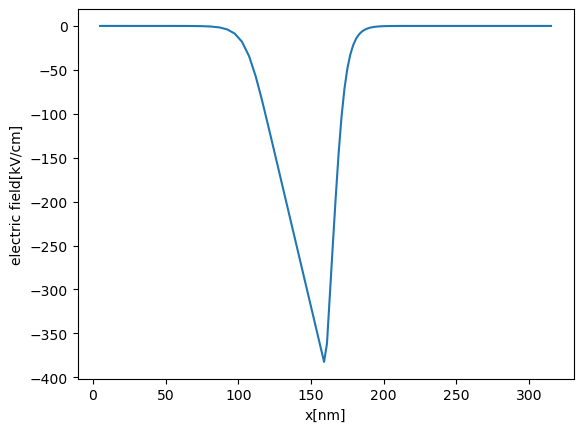

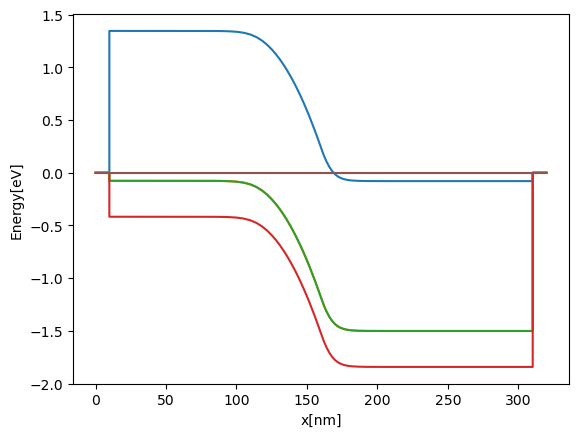

In [10]:
strain_datafile = nn.DataFile(electric_field_file, product='nextnano++')
strain_datafile.plot(y_axis_name = 'electric field')
bandstructure_datafile = nn.DataFile(bulk_bandstructure)
print(bandstructure_datafile)
bandstructure_datafile.plot(y_axis_name = 'Energy')

_Note: if DataFile contains no variables, the first variable is taken as coordinate to plot(as in example for bandstructure, |k| is a variable, but used as coordinate to plot_

# Find the files by keyword

The DataFodlder class can be also used to find files with a certain keyword.

``` python
DataFolder.find('keyword', deep = False) #-> return list of files containing a keyword in the current directory 
DataFolder.find('keyword', deep = True ) #-> return list of files containing a keyword in the current directory and all subdirectories 
```

The default value of ```deep``` is False.

In [11]:
my_datafolder.find('simulation', deep = False)


['/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/simulation_database.txt',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/simulation_info.txt',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/simulation_input.txt']

In [12]:
my_datafolder.find('variables', deep = False)

['/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/variables_database.txt',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/variables_input.txt']

In [13]:
my_datafolder.find('density', deep = True)

['/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/Structure/density_acceptor.dat',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/Structure/density_donor.dat',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/Structure/density_fixed_charge.dat',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/Structure/density_intrinsic.dat',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/bias_00000/density_acceptor_ionized.dat',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/bias_00000/density_donor_ionized.dat',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/bias_00000/density_electron.dat',
 '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/pn_junction_GaAs_1D_demo/bias_00000/density_hole.dat']

This can be used, for example, to plot all files containing keyword 'density'

In [14]:
all_densities = my_datafolder.find('density', deep = True)

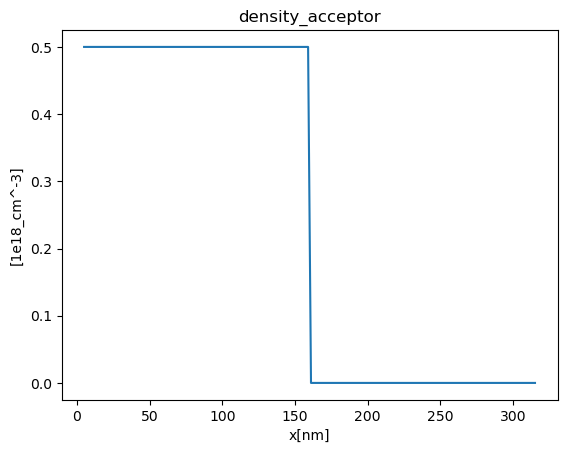

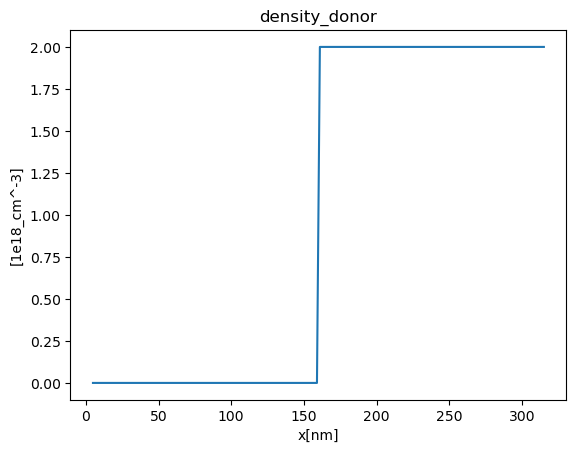

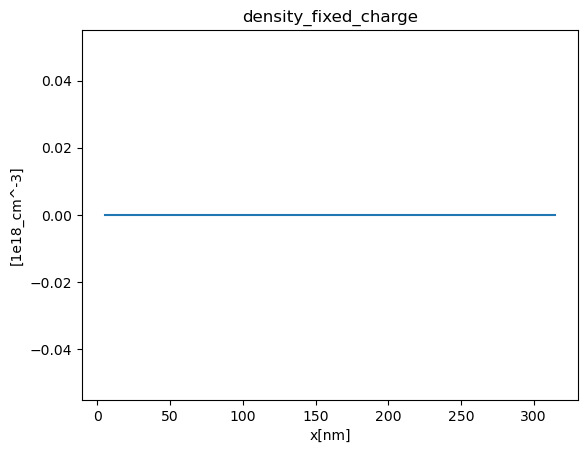

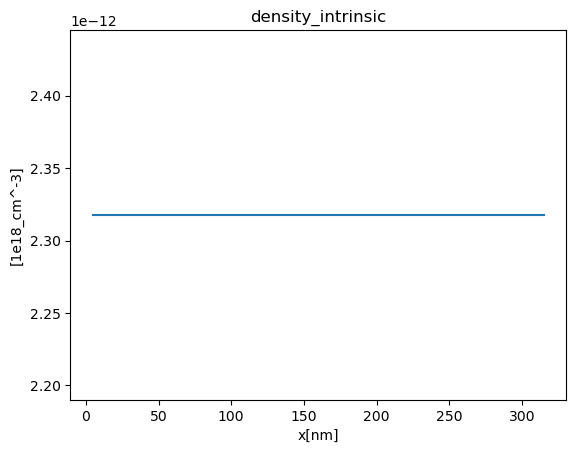

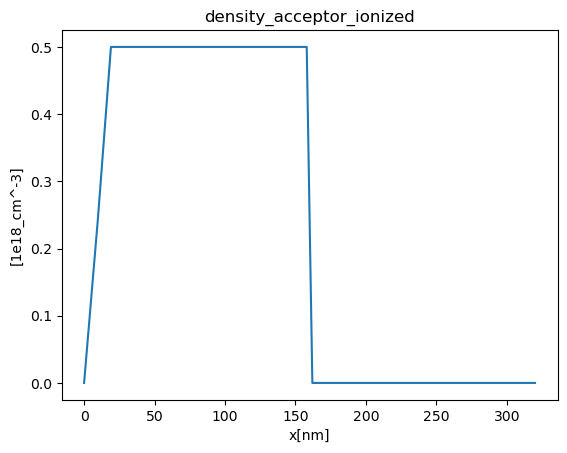

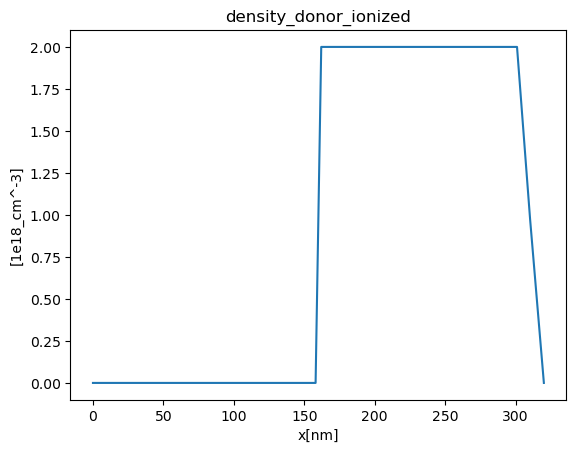

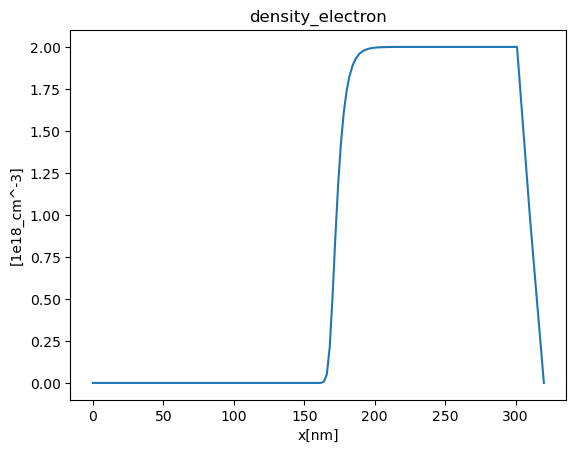

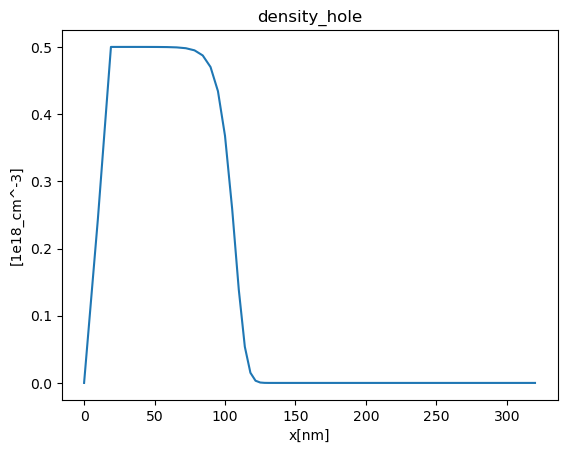

In [15]:
import matplotlib.pyplot as plt

for density in all_densities:
    density_df = nn.DataFile(density, product = 'nextnano++')
    filename = density_df.filename_only
    density_df.plot()
    plt.title(filename)



Please contact python@nextnano.com for any issues with this document.